In [153]:
import pandas as pd, numpy as np, os

In [154]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [155]:
BASE_DIR = Path.cwd().parent / 'datasets'

In [156]:
print(BASE_DIR)

/home/toqeer-yasir/Documents/repos/deep-learning/Deep_learning/datasets


In [157]:
df = pd.read_csv(BASE_DIR/'churn_modelling.csv')

In [158]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [160]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [161]:
df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [162]:
# now we need to do onehot endcoding to convert string data into numbers
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [163]:
df.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False


In [164]:
len(df.columns)

12

In [165]:
X = df.drop(columns=['Exited']).values

In [166]:
y = df['Exited'].values

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

In [168]:
scaler = StandardScaler()

In [169]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [170]:
X_train_scaled[:5]

array([[-1.10279008, -1.61654412,  1.02429474, -1.21796197,  0.79977573,
        -1.54127461, -1.02173618,  0.48419792, -0.58004459, -0.57311631,
         0.90293624],
       [-0.13602354, -1.13942003, -1.38996956, -1.21796197,  0.79977573,
         0.64881365, -1.02173618, -0.14683916, -0.58004459, -0.57311631,
         0.90293624],
       [ 0.38849873, -0.9485704 , -1.38996956, -1.21796197,  0.79977573,
         0.64881365, -1.02173618,  0.95549956, -0.58004459, -0.57311631,
         0.90293624],
       [ 2.0546283 ,  0.57822668, -0.35528486,  0.61282742,  0.79977573,
         0.64881365,  0.97872623,  0.16259138, -0.58004459,  1.74484652,
        -1.10749791],
       [ 0.61476324, -0.75772076, -1.38996956, -1.21796197,  0.79977573,
         0.64881365, -1.02173618, -1.38488363, -0.58004459, -0.57311631,
        -1.10749791]])

In [171]:
model = Sequential()

In [172]:
model.add(Input(shape=(11,)))
model.add(Dense(3, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [173]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [174]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [175]:
history = model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7903 - loss: 0.5507 - val_accuracy: 0.7862 - val_loss: 0.5267
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7958 - loss: 0.5002 - val_accuracy: 0.7856 - val_loss: 0.4984
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4767 - val_accuracy: 0.7856 - val_loss: 0.4823
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.4616 - val_accuracy: 0.7856 - val_loss: 0.4705
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7955 - loss: 0.4504 - val_accuracy: 0.7850 - val_loss: 0.4617
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.4422 - val_accuracy: 0.7862 - val_loss: 0.4554
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.4360 - val_accuracy: 0.7900 - val_loss: 0.4508
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8031 - loss: 0.4315 - val_accuracy: 0.

In [176]:
model.layers[0].get_weights()

[array([[-0.03597739,  0.07772543,  0.18160911],
        [ 2.3093512 , -0.09705359, -1.497476  ],
        [-0.08749771, -0.06650648,  0.08739688],
        [ 0.28371707,  0.41469157, -0.295775  ],
        [ 0.2980065 ,  1.689238  , -0.15673049],
        [ 0.12216044,  0.10821903, -0.15186714],
        [-0.05633764,  0.6409004 ,  0.77468413],
        [-0.18092908, -0.10278927, -0.1563886 ],
        [ 0.30224764, -0.586372  , -0.4637435 ],
        [ 0.2217931 , -0.18529254,  0.30949238],
        [-0.3087358 ,  0.02495279,  0.50713015]], dtype=float32),
 array([-0.23516028,  0.941776  ,  0.5286814 ], dtype=float32)]

In [177]:
model.layers[0].get_weights()

[array([[-0.03597739,  0.07772543,  0.18160911],
        [ 2.3093512 , -0.09705359, -1.497476  ],
        [-0.08749771, -0.06650648,  0.08739688],
        [ 0.28371707,  0.41469157, -0.295775  ],
        [ 0.2980065 ,  1.689238  , -0.15673049],
        [ 0.12216044,  0.10821903, -0.15186714],
        [-0.05633764,  0.6409004 ,  0.77468413],
        [-0.18092908, -0.10278927, -0.1563886 ],
        [ 0.30224764, -0.586372  , -0.4637435 ],
        [ 0.2217931 , -0.18529254,  0.30949238],
        [-0.3087358 ,  0.02495279,  0.50713015]], dtype=float32),
 array([-0.23516028,  0.941776  ,  0.5286814 ], dtype=float32)]

In [178]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.06936578]
 [0.11249156]
 [0.0363955 ]
 [0.06005963]
 [0.11652509]]


In [179]:
y_pred = np.where(y_pred> 0.5, 1, 0)

In [180]:
from sklearn.metrics import accuracy_score

In [181]:
accuracy_score(y_test, y_pred)*100

82.3

In [182]:
import  matplotlib.pyplot as plt

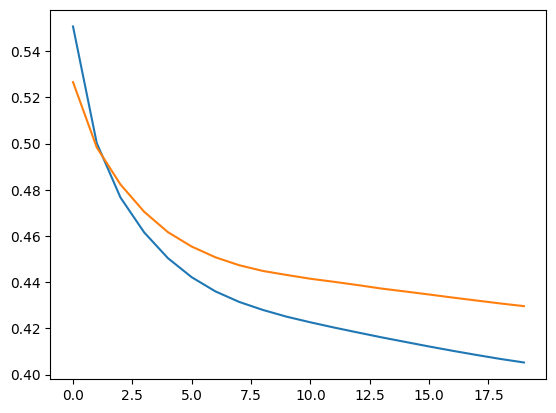

In [184]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

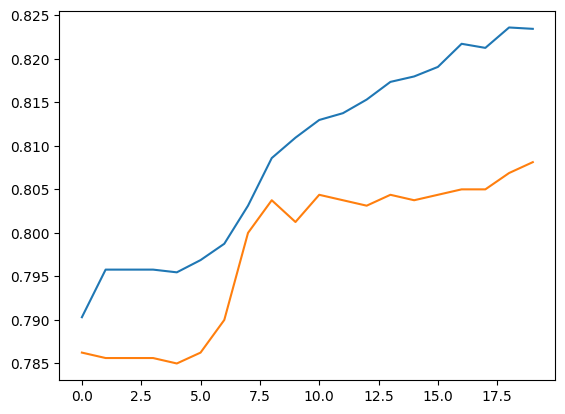

In [185]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])